In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA
import random
import math
import scipy.stats as stats
import scipy.io 
import scipy.integrate as integrate
from numba import jit, int32
import numba
import time


In [2]:
#Model parameters

c1 = 0.5
xi = 8.5
q_c = 7
q_e = 0.093
tau_q = 15
T_mean = 16.6
alpha_q = q_c*q_e*np.exp(q_e*T_mean)/tau_q
gamma = 5.6

chi_A = 0.31
chi_O = 1.38

Q_mean = 0.9

dA = 0.1
dO = 0.5

re = 0.5
rw = 0.5

a = chi_O*c1*gamma
b = c1*xi*alpha_q

Q1 =  chi_A*alpha_q/(2 - 2*Q_mean)
Q2 =  chi_A*alpha_q/(3 - 3*Q_mean)



mu = 0.04

In [3]:
LO = 6/5
LA = 8/3

NO = 168


xO = np.linspace(0,LO,NO)
dxO = xO[1] - xO[0]


t_f = 2*9.6
t_N = 3*960


t = np.linspace(0,t_f,t_N)
dt = t[1] - t[0]


c1 = 0.5





r_K = np.exp(-dA*(LA-LO))
r_R = np.exp(3*dA*(LA-LO))

KA = np.zeros((t_N,NO))
RA = np.zeros((t_N,NO))
KA_sum = np.zeros((t_N,NO))
RA_sum = np.zeros((t_N,NO))

KO = np.zeros((t_N,NO))
RO = np.zeros((t_N,NO))

T = np.zeros((t_N,NO))

KO[0,:] = 0.6*np.linspace(0.5, 0.25 ,NO)
RO[0,0] = (1/rw)*KO[0,0]
RO[0,NO-1] = re*KO[0,NO-1]
RO[0,:] = np.linspace(RO[0,0] , RO[0,NO-1]  ,NO)


V_K = np.zeros((t_N))
V_R = np.zeros((t_N))

eta = 1.5 + (0.5*np.tanh(7.5*(xO - LO/2)))

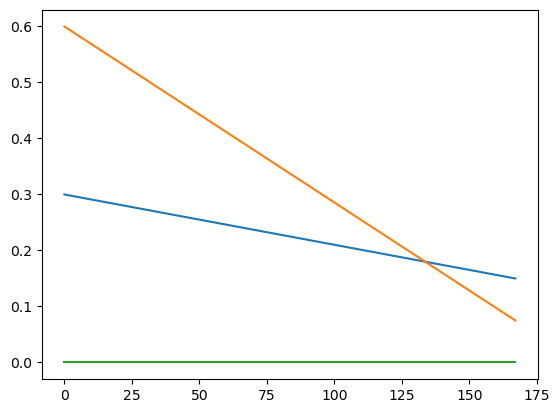

In [4]:
plt.plot(KO[0,:])
plt.plot(RO[0,:])
plt.plot(T[0,:])

In [5]:
start = time.time()
for i in range(t_N-1):
    V_K[0] = sum(Q1*(np.exp(-dA*LO))*np.exp(dA*xO[j-1])*(T[0,j]+T[0,j-1])*dxO/2 for j in range(1,NO)) 
    V_R[0] = sum(-3*Q2*(np.exp(3*dA*LO))*np.exp(-3*dA*xO[j-1])*(T[0,j]+T[0,j-1])*dxO/2 for j in range(1,NO)) 
    for j in range(0,NO):
        KA[0,j] = V_K[0]*np.exp(-dA*xO[j])/(r_K - np.exp(-dA*LO)) + sum(Q1*np.exp(-dA*xO[j])*np.exp(dA*xO[k-1])*(T[0,k]+T[0,k-1])*dxO/2  for k in range(1,j+1)) 
        RA[0,j] = V_R[0]*np.exp(3*dA*xO[j])/(r_R - np.exp(3*dA*LO)) + sum(-3*Q2*np.exp(3*dA*xO[j])*np.exp(-3*dA*xO[k-1])*(T[0,k]+T[0,k-1])*dxO/2  for k in range(1,j+1))  
    for j in range(1,NO):  
        KO[i+1,j] = KO[i,j] - (c1)*(dt/dxO)*((KO[i,j] - KO[i,j-1])) - dt*dO*KO[i,j] + dt*(a/2)*(KA[i,j] - RA[i,j]) 
        KO[i+1,0] = KO[i,0] - (c1)*(dt/dxO)*(KO[i,0] - rw*RO[i,0])  - dt*dO*KO[i,0] + dt*(a/2)*(KA[i,0] - RA[i,0])                                                                                                                 
    for j in range(0,NO-1):
        RO[i+1,j] = RO[i,j] + (c1/3)*(dt/dxO)*((RO[i,j+1] - RO[i,j])) - dt*dO*RO[i,j] - dt*(a/3)*(KA[i,j] - RA[i,j]) 
        RO[i+1,NO-1] = RO[i,NO-1] + (c1/3)*(dt/dxO)*(re*KO[i,NO-1] - RO[i,NO-1]) - dt*dO*RO[i,NO-1] - dt*(a/3)*(KA[i,NO-1] - RA[i,NO-1]) 
    for j in range(1,NO-1):    
        T[i+1,0] = T[i,0] - (dt/dxO)*mu*((KO[i,0] - rw*RO[i,0])*T[i,0] - (RO[i,1] - RO[i,0])*T[i,0] - (T[i,1] - T[i,0])*RO[i,0])  -  dt*b*T[i,0] + (c1)*(dt)*(eta[0])*(KO[i,0] + RO[i,0])
        T[i+1,j] = T[i,j] - (dt/dxO)*mu*((KO[i,j] - KO[i,j-1])*T[i,j] - (RO[i,j+1] - RO[i,j])*T[i,j] + (T[i,j] - T[i,j-1])*KO[i,j] - (T[i,j+1] - T[i,j])*RO[i,j])  -  dt*b*T[i,j] + (c1)*(dt)*(eta[j])*(KO[i,j] + RO[i,j]) 
        T[i+1, NO-1] = T[i+1,NO-2]
    V_K[i+1] = sum(Q1*(np.exp(-dA*LO))*np.exp(dA*xO[j-1])*(T[i+1,j]+T[i+1,j-1])*dxO/2 for j in range(1,NO))
    V_R[i+1] = sum(-3*Q2*(np.exp(3*dA*LO))*np.exp(-3*dA*xO[j-1])*(T[i+1,j]+T[i+1,j-1])*dxO/2 for j in range(1,NO))
    for j in range(0,NO):
        KA[i+1,j] = V_K[i+1]*np.exp(-dA*xO[j])/(r_K - np.exp(-dA*LO)) + sum( Q1*np.exp(-dA*xO[j])*np.exp(dA*xO[k-1])*(T[i+1,k]+T[i+1,k-1])*dxO/2  for k in range(1,j+1))
        RA[i+1,j] = V_R[i+1]*np.exp(3*dA*xO[j])/(r_R - np.exp(3*dA*LO)) + sum(-3*Q2*np.exp(3*dA*xO[j])*np.exp(-3*dA*xO[k-1])*(T[i+1,k]+T[i+1,k-1])*dxO/2  for k in range(1,j+1))
end = time.time()
print(end - start)                            

501.8733651638031


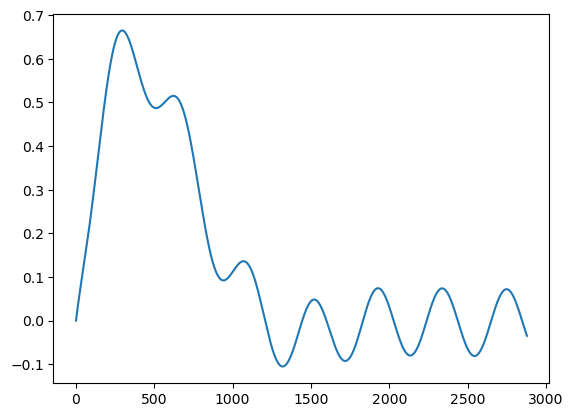

In [6]:
plt.plot(T[:,1])

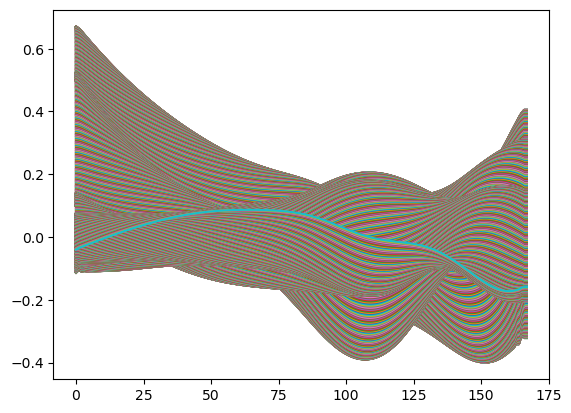

In [7]:
for k in range(t_N):
    plt.plot(T[k,:])

In [8]:
scipy.io.savemat('Coupled_NonLinear_1_1.mat', {'Kelvin_Atmosphere': KA, 'Rossby_Atmosphere' : RA, 'Kelvin_Ocean' : KO, 'Rossby_Ocean' : RO, 
                                                    'Temperature' : T}) 